## LABOR: SDR-Radiolink — 433 MHz ISM

← [SDR-Kalibrierung](SDR-calibration.ipynb)

Ein **433-MHz-ISM-Sender** strahlt einen **unmodulierten Träger** nahe **433,9 MHz** mit einer Sendeleistung ab, die vom Betreuer **bekanntgegeben** wird. Die folgenden Aufgaben sind mit dem SDR im Labor durchzuführen.

**Hinweis:** Der Kalibrierungs-Offset für die Umrechnung der FFT-Werte in Eingangsleistung (dBm) wird im Notebook **SDR-calibration.ipynb** ermittelt und in **calibration.json** abgelegt. Falls diese Datei noch nicht existiert (z. B. andere Reihenfolge der Messungen), wird ein **Default-Offset von -100 dB** verwendet (d. h. ermittelter numerischer Wert + Offset = angenommene Eingangsleistung in dBm).

### Windows: Treiber-Pfad setzen (vor dem Import)

Falls du unter Windows arbeitest: Zelle ausführen, damit **librtlsdr.dll** gefunden wird.

In [5]:
import os
from pathlib import Path

_driver_dir = None
for p in [Path.cwd()] + list(Path.cwd().parents):
    candidate = p / "rtl-sdr-driver"
    if candidate.exists() and (candidate / "librtlsdr.dll").exists():
        _driver_dir = candidate
        break
if _driver_dir is not None:
    _path = str(_driver_dir)
    os.environ["PATH"] = _path + os.pathsep + os.environ.get("PATH", "")
    if hasattr(os, "add_dll_directory"):
        os.add_dll_directory(_path)
    print("RTL-SDR Treiber gefunden:", _driver_dir)
else:
    print("Hinweis: rtl-sdr-driver (librtlsdr.dll) nicht gefunden.")

RTL-SDR Treiber gefunden: C:\Users\ralfk\GIT_KT\rtl-sdr-driver


### Parameter und Kalibrierung laden

Kalibrationsdatei **calibration.json** (aus SDR-calibration.ipynb) laden. Falls nicht vorhanden: Default-Offset = **-100 dB + gain_dB** verwenden (numerische FFT-Werte + Offset = angenommene Eingangsleistung in dBm).

In [6]:
import json
import numpy as np
import matplotlib.pyplot as plt


CENTER_FREQ_HZ = 433.9e6
NUM_SAMPLES = 4096
NUM_AVERAGES = 32
SAMPLE_RATE_HZ = 2.048e6
GAIN_DB = 20.0  # Gain für Messung (sollte zu einem Eintrag in calibration.json passen)

CALIBRATION_PATH = Path.cwd() / "calibration.json"
DEFAULT_OFFSET_DB = -100.0 - GAIN_DB # Fallback, wenn calibration.json fehlt

def load_calibration(path=None):
    path = path or CALIBRATION_PATH
    if not path.exists():
        return None
    with open(path, encoding="utf-8") as f:
        return json.load(f)

def get_calibration_offset_dB(gain_db):
    cal = load_calibration()
    if cal is None:
        return DEFAULT_OFFSET_DB
    gains = cal.get("gains", [])
    for g in gains:
        if g["gain_dB"] == gain_db:
            return g["calibration_offset_dB"]
    # Nähesten Gain verwenden
    if not gains:
        return DEFAULT_OFFSET_DB
    best = min(gains, key=lambda x: abs(x["gain_dB"] - gain_db))
    return best["calibration_offset_dB"]

cal = load_calibration()
offset_dB = get_calibration_offset_dB(GAIN_DB)
print(f"Kalibrierung: {'geladen' if cal else 'nicht vorhanden (Default -100 dB)'}")
print(f"Verwendeter Kalibrierungs-Offset für Gain {GAIN_DB} dB: {offset_dB} dB")

Kalibrierung: geladen
Verwendeter Kalibrierungs-Offset für Gain 20.0 dB: -141.0897 dB


---

### Aufgabe A: Spektralanalyse, Trägerleistung, Rauschleistungsdichte, $C/N_0$

1. **Empfang:** Signal mit dem SDR bei **Mittenfrequenz 433,9 MHz** einlesen, **M = 32** Betragsspektren mitteln und eine **Spektralanalyse mit N = 4096** Punkten durchführen.

2. **Trägerleistung:** Im gemittelten Betragsspektrum die **Leistung des empfangenen Trägers in dBm** bestimmen. Dazu einen **Kalibrierungs-Offset K (dB)** verwenden, der die numerischen FFT-Werte so kalibriert, dass die **Eingangsleistung an der Antenne** in dBm dargestellt wird. Dieser Offset stammt aus **calibration.json** (ermittelt in SDR-calibration.ipynb); falls die Datei fehlt, **Default-Offset -100 dB** verwenden.

3. **Rauschleistungsdichte:** Die **Leistungsdichte des Rauschbodens in dBm/Hz** ermitteln. Dafür die **gemessene Rauschleistung pro Frequenz-Bin** und die **„Bandbreite“ eines Bins** (entspricht der **FFT-Auflösung**) heranziehen; die Bin-Bandbreite ist zu berechnen.

4. **$C/N_0$:** Das **normierte Signal-zu-Rauschleistungsverhältnis $C/N_0$** (in dB-Hz) angeben.

5. **Plots:** Das **gemittelte Betragsspektrum** darstellen:
   - **Einmal** mit den **gerechneten (numerischen)** Werten (z. B. in dB).
   - **Einmal** mit den **kalibrierten** Werten (dBm), sofern **calibration.json** vorhanden ist.

---

### Aufgabe B: SNR(B) und Kanalkapazität

Basierend auf dem ermittelten **$C/N_0$**:

1. **SNR in Abhängigkeit von der Bandbreite:** Das **SNR** für Bandbreiten **B von 0 Hz bis 2 MHz** berechnen und **als Funktion von B** plotten.

2. **Kanalkapazität:** Die **Kanalkapazität $C(B)$** als Funktion der Bandbreite **B** berechnen und plotten.

Damit soll gezeigt werden, welche **maximalen Datenraten** mit diesem realistischen Laborsetup erzielt werden könnten.

---

### Parameter (vom Betreuer vorgegeben / anpassbar)

- Mittenfrequenz (z. B. 433,9 MHz), Gain (dB)
- **N** = 4096 (FFT-Länge), **M** = 32 (Anzahl gemittelter Betragsspektren)
- Sample-Rate des SDR (z. B. 2,048 MS/s)
- **calibration.json** im gleichen Ordner; falls nicht vorhanden: **Default-Offset -100 dB**

## Aufgabe A: SDR einlesen, M Betragsspektren mitteln, Peak und Noisefloor ermitteln
 Bin-Bandbreite = FFT-Auflösung = f_s / N
 Trägerleistung (dBm), Rauschleistungsdichte N0 (dBm/Hz), C/N0 (dB-Hz)
 ... (von dir zu implementieren)

In [9]:
# Aufgabe A: Spektralanalyse, Trägerleistung, Rauschleistungsdichte N0, C/N0

from pathlib import Path
import json
import numpy as np

# ------------------------------------------------------------
# 1) Messdaten laden
# ------------------------------------------------------------
# Hier wird die bereitgestellte Labordatei verwendet.
# Falls du stattdessen live vom SDR messen willst, müsstest du an dieser Stelle
# die Samples vom SDR einlesen und in "samples" speichern.

npz_path = Path.cwd() / "sdr_logs" / "sdr_lab_check.npz"
if not npz_path.exists():
    raise FileNotFoundError("sdr_lab_check.npz nicht gefunden.")

lab_data = np.load(npz_path)
samples = lab_data["samples"]                 # komplexe IQ-Samples
meta = json.loads(str(lab_data["meta"]))      # Metadaten als dict

# Metadaten aus der Datei verwenden
CENTER_FREQ_HZ = float(meta["center_freq_hz"])
SAMPLE_RATE_HZ = float(meta["sample_rate_hz"])
GAIN_DB = float(meta["gain_db"])
NUM_SAMPLES = int(meta["num_samples"])
NUM_AVERAGES = int(meta["num_blocks"])

# Sicherheitscheck: Länge muss M*N sein
expected_len = NUM_AVERAGES * NUM_SAMPLES
if len(samples) != expected_len:
    raise ValueError(
        f"Unerwartete Anzahl Samples: {len(samples)} "
        f"(erwartet: {expected_len} = {NUM_AVERAGES} * {NUM_SAMPLES})"
    )

# ------------------------------------------------------------
# 2) Kalibrierungs-Offset laden
# ------------------------------------------------------------
CALIBRATION_PATH = Path.cwd() / "calibration.json"
DEFAULT_OFFSET_DB = -100.0 - GAIN_DB

def load_calibration(path=None):
    path = path or CALIBRATION_PATH
    if not path.exists():
        return None
    with open(path, encoding="utf-8") as f:
        return json.load(f)

def get_calibration_offset_dB(gain_db):
    cal = load_calibration()
    if cal is None:
        return DEFAULT_OFFSET_DB

    gains = cal.get("gains", [])
    for g in gains:
        if float(g["gain_dB"]) == float(gain_db):
            return float(g["calibration_offset_dB"])

    # Falls exakter Gain nicht vorhanden: nächstliegenden Gain verwenden
    if not gains:
        return DEFAULT_OFFSET_DB

    best = min(gains, key=lambda x: abs(float(x["gain_dB"]) - float(gain_db)))
    return float(best["calibration_offset_dB"])

offset_dB = get_calibration_offset_dB(GAIN_DB)

# ------------------------------------------------------------
# 3) FFT-Bandbreite berechnen
# ------------------------------------------------------------
# FFT-Auflösung = fs / N
bin_bandwidth_hz = SAMPLE_RATE_HZ / NUM_SAMPLES

# ------------------------------------------------------------
# 4) Samples in M Blöcke zu je N Samples aufteilen
# ------------------------------------------------------------
blocks = samples.reshape(NUM_AVERAGES, NUM_SAMPLES)

# ------------------------------------------------------------
# 5) Für jeden Block FFT berechnen und Betrag bilden
# ------------------------------------------------------------
# fftshift: damit 0 Hz in der Mitte liegt
X = np.fft.fftshift(np.fft.fft(blocks, axis=1), axes=1)

# Betragsspektren
magnitude = np.abs(X)

# Über M=32 Betragsspektren mitteln
magnitude_avg = np.mean(magnitude, axis=0)

# ------------------------------------------------------------
# 6) Frequenzachse erzeugen
# ------------------------------------------------------------
freq_axis_hz = CENTER_FREQ_HZ + np.fft.fftshift(
    np.fft.fftfreq(NUM_SAMPLES, d=1 / SAMPLE_RATE_HZ)
)
freq_mhz = freq_axis_hz / 1e6

# ------------------------------------------------------------
# 7) Numerisches Betragsspektrum in dB
# ------------------------------------------------------------
# Da magnitude_avg ein Amplitudenwert ist:
# dB = 20*log10(Amplitude)
magnitude_dB_raw = 20 * np.log10(magnitude_avg + 1e-20)

# ------------------------------------------------------------
# 8) Kalibriertes Spektrum in dBm
# ------------------------------------------------------------
# numerischer dB-Wert + Kalibrierungs-Offset
magnitude_dBm_cal = magnitude_dB_raw + offset_dB

# ------------------------------------------------------------
# 9) Peak suchen -> Träger
# ------------------------------------------------------------
peak_bin = int(np.argmax(magnitude_dBm_cal))
peak_freq_hz = float(freq_axis_hz[peak_bin])
carrier_dBm = float(magnitude_dBm_cal[peak_bin])

# ------------------------------------------------------------
# 10) Rauschleistungsdichte N0 berechnen
# ------------------------------------------------------------
# Um den Träger herum einige Bins ausschließen, damit das Signal
# die Rauschschätzung nicht verfälscht.
exclude_bins = 3
mask = np.ones_like(magnitude_dBm_cal, dtype=bool)
mask[max(0, peak_bin - exclude_bins): min(len(mask), peak_bin + exclude_bins + 1)] = False

# Mittelwert der Rauschleistung pro Bin in linearer Leistung (mW)
# Wichtig: Nicht direkt dB-Werte mitteln!
noise_power_per_bin_mW = np.mean(10 ** (magnitude_dBm_cal[mask] / 10.0))

# Zurück nach dBm pro Bin
noise_power_per_bin_dBm = 10 * np.log10(noise_power_per_bin_mW)

# Von "pro Bin" auf "pro Hz" umrechnen:
# N0 = P_noise_bin - 10*log10(Binbreite)
N0_dBm_per_Hz = float(noise_power_per_bin_dBm - 10 * np.log10(bin_bandwidth_hz))

# ------------------------------------------------------------
# 11) C/N0 berechnen
# ------------------------------------------------------------
CN0_dBHz = float(carrier_dBm - N0_dBm_per_Hz)

# ------------------------------------------------------------
# 12) Ausgabe
# ------------------------------------------------------------
print(f"Verwendete Messdatei: {npz_path.name}")
print(f"Center-Frequenz: {CENTER_FREQ_HZ/1e6:.6f} MHz")
print(f"Sample-Rate: {SAMPLE_RATE_HZ/1e6:.6f} MS/s")
print(f"N = {NUM_SAMPLES}, M = {NUM_AVERAGES}")
print(f"Gain: {GAIN_DB:.1f} dB")
print(f"Kalibrierungs-Offset: {offset_dB:.4f} dB")
print()

print(f"Bin-Bandbreite (FFT-Auflösung): {bin_bandwidth_hz:.1f} Hz")
print(f"Peak bei Bin {peak_bin}, Frequenz {peak_freq_hz/1e6:.6f} MHz")
print(f"Trägerleistung (kalibriert): {carrier_dBm:.2f} dBm")
print(f"Rauschleistung pro Bin: {noise_power_per_bin_dBm:.2f} dBm")
print(f"Rauschleistungsdichte N0: {N0_dBm_per_Hz:.2f} dBm/Hz")
print(f"C/N0 = {CN0_dBHz:.2f} dB-Hz")

Verwendete Messdatei: sdr_lab_check.npz
Center-Frequenz: 433.900000 MHz
Sample-Rate: 2.048000 MS/s
N = 4096, M = 32
Gain: 20.0 dB
Kalibrierungs-Offset: -141.0897 dB

Bin-Bandbreite (FFT-Auflösung): 500.0 Hz
Peak bei Bin 1939, Frequenz 433.845500 MHz
Trägerleistung (kalibriert): -90.97 dBm
Rauschleistung pro Bin: -134.17 dBm
Rauschleistungsdichte N0: -161.16 dBm/Hz
C/N0 = 70.18 dB-Hz


### Plotte gemitteltes Betragsspektrum einmal numerisches Ergebnis (magnitude_dB_raw) , einmal kalibriert (magnitude_dBm_cal in dBm)
... (von dir zu implementieren)

magnitude_dB_raw = ?  # diese Leistung ist nur ein numerischer Wert aus der Spektralanalyse
magnitude_dBm_cal = ? # diese Leistung ist der numerische Wert + Offset und ergibt die kalibrierte Leistung in dBm


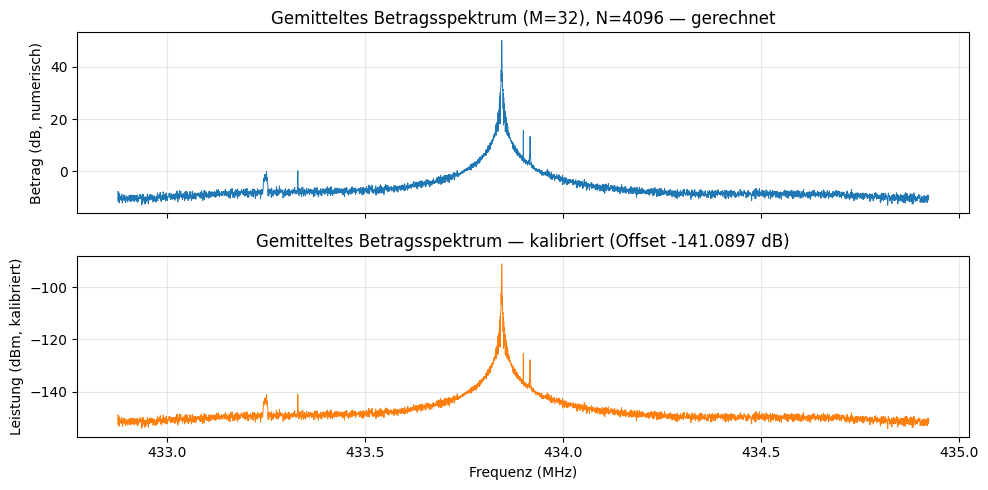

In [10]:

# Plotten von magnitude_dB_raw und magnitude_dBm_cal   

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
ax1.plot(freq_mhz, magnitude_dB_raw, color="C0", linewidth=0.7)
ax1.set_ylabel("Betrag (dB, numerisch)")
ax1.set_title("Gemitteltes Betragsspektrum (M=32), N=4096 — gerechnet")
ax1.grid(True, alpha=0.3)

ax2.plot(freq_mhz, magnitude_dBm_cal, color="C1", linewidth=0.7)
ax2.set_xlabel("Frequenz (MHz)")
ax2.set_ylabel("Leistung (dBm, kalibriert)")
ax2.set_title("Gemitteltes Betragsspektrum — kalibriert (Offset {} dB)".format(offset_dB))
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
# Aufgabe B: SNR(B) und Kanalkapazität C(B) für B von 0 bis 2 MHz berechnen und plotten
# ... (von dir zu implementieren)
# Aufgabe B: SNR(B) und Kanalkapazität C(B) für B von 0 bis 2 MHz berechnen und plotten

import numpy as np
import matplotlib.pyplot as plt

B_Hz = np.linspace(100, 2e6, 500)  # 100 Hz bis 2 MHz

# SNR aus C/N0
SNR_dB = CN0_dBHz - 10 * np.log10(B_Hz)
SNR_linear = 10 ** (SNR_dB / 10)

# Shannon-Kapazität
capacity_bps = B_Hz * np.log2(1 + SNR_linear)

print(f"Bei B = 2 MHz: SNR ≈ {SNR_dB[-1]:.1f} dB, C ≈ {capacity_bps[-1]/1e6:.2f} Mbit/s")

Bei B = 2 MHz: SNR ≈ 7.2 dB, C ≈ 5.27 Mbit/s


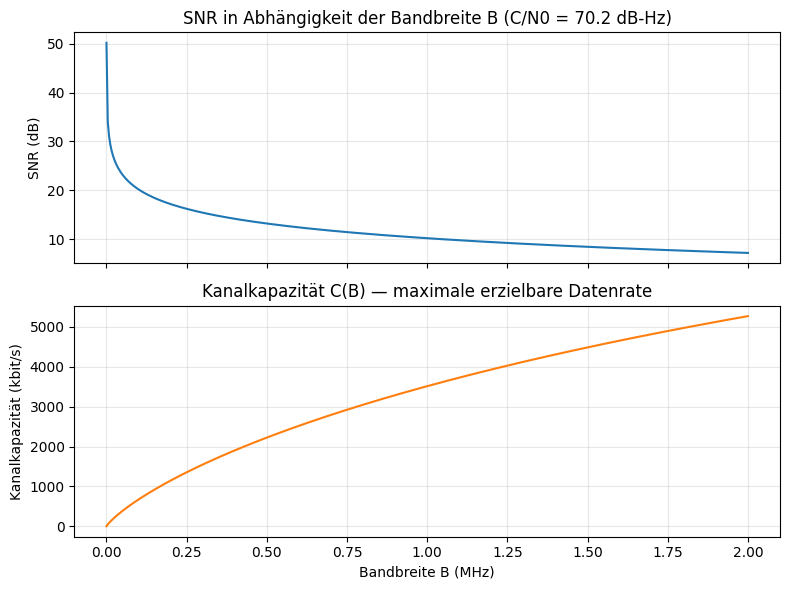

Bei B = 2 MHz: SNR ≈ 7.2 dB, C ≈ 5.27 Mbit/s


In [14]:
B_Hz = np.linspace(100, 2e6, 500)  # 100 Hz bis 2 MHz
SNR_dB = CN0_dBHz - 10 * np.log10(B_Hz)
SNR_linear = 10 ** (SNR_dB / 10)
capacity_bps = B_Hz * np.log2(1 + SNR_linear)  # bit/s

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
ax1.plot(B_Hz / 1e6, SNR_dB, color="C0")
ax1.set_ylabel("SNR (dB)")
ax1.set_title("SNR in Abhängigkeit der Bandbreite B (C/N0 = {:.1f} dB-Hz)".format(CN0_dBHz))
ax1.grid(True, alpha=0.3)

ax2.plot(B_Hz / 1e6, capacity_bps / 1e3, color="C1")
ax2.set_xlabel("Bandbreite B (MHz)")
ax2.set_ylabel("Kanalkapazität (kbit/s)")
ax2.set_title("Kanalkapazität C(B) — maximale erzielbare Datenrate")
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Bei B = 2 MHz: SNR ≈ {SNR_dB[-1]:.1f} dB, C ≈ {capacity_bps[-1]/1e6:.2f} Mbit/s")